# Sesión 1 · Mezclas gaussianas: grupos que se superponen
**14 de septiembre · 120 minutos · Caso de movilidad urbana**

Al terminar: derivar un paso EM, interpretar pesos y covarianzas, distinguir responsabilidad y densidad,
y justificar una selección de componentes. Leer primero las secciones 1–3 de las notas matemáticas.

Los datos suministrados no acreditan su proveedor. Estudiamos ubicaciones observadas, sin etiquetas de barrios
ni cobertura conocida del mercado. Una componente es una representación estadística, no una zona administrativa.

In [1]:
from pathlib import Path
import sys, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from threadpoolctl import threadpool_limits

# Funciona desde la raíz, desde esta carpeta o desde docente/.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'datasets/semana-08').is_dir())
sys.path.insert(0, str(ROOT / 'notebooks/semana-08'))
from movilidad import (load_data, setup, savefig, save_table, spatial_axes,
                       ellipses, safe_silhouette, density_grid, COLORS, DATA)
setup()
threadpool_limits(limits=2)
frame = load_data()
X = frame[['x_km', 'y_km']].to_numpy()
print(f'Desarrollo: {len(frame):,} recogidas. Unidades: km. Semilla: 42.')
print('Test temporal cerrado hasta congelar el modelo.')
display(frame.head(3))

Desarrollo: 6,000 recogidas. Unidades: km. Semilla: 42.
Test temporal cerrado hasta congelar el modelo.


,source_row,pickup_datetime,pickup_longitude,pickup_latitude,x_km,y_km,fare_amount,passenger_count,dropoff_longitude,dropoff_latitude
0,32038,2014-01-01 00:01:00+00:00,-73.991493,40.735202,0.156182,-0.148260,5.5,5,-74.001727,40.727767
1,132584,2014-01-01 00:29:37+00:00,-74.008090,40.740434,-1.251817,0.416562,8.0,2,-73.996088,40.726627
2,190530,2014-01-01 00:54:07+00:00,-73.981944,40.778096,0.907251,4.622599,7.5,1,-73.967887,40.801430


## 1. ¿Qué hay detrás del mapa?
La auditoría usa reglas secuenciales; sus filas suman el total original. Estar fuera del área no es sinónimo de error.
Las coordenadas cero no pertenecen a este caso. No filtramos por tarifa porque no entra en el modelo espacial.
La proyección UTM mantiene unidades comparables en ambos ejes; un escalado independiente deformaría las distancias.

,motivo,n,porcentaje
0,apto_area_fecha,195871,97.9355
1,coordenada_cero_fuera_del_caso,3789,1.8945
2,fuera_area_de_estudio,330,0.1650
3,coordenada_imposible,10,0.0050


Original: 200000 | 2014 en el área: 29340


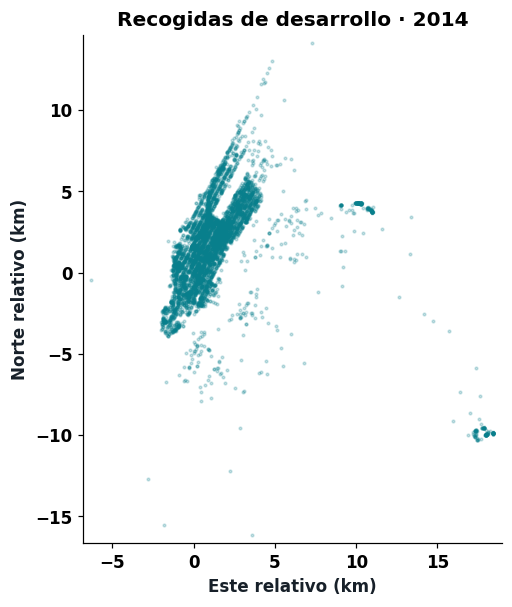

In [2]:
display(pd.read_csv(DATA / 'auditoria.csv'))
manifest = json.loads((DATA / 'manifest.json').read_text(encoding='utf-8'))
print('Original:', manifest['rows_raw'], '| 2014 en el área:', manifest['rows_2014_area'])
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(*X.T, s=3, alpha=.22, color=COLORS[0])
spatial_axes(ax, X, 'Recogidas de desarrollo · 2014')
savefig(fig, '01_recogidas')

### Para resolver

Antes de ajustar: ¿cuántos grupos ves? Dibuja dos particiones plausibles. ¿Qué podría significar un punto aislado?

**Mi respuesta y evidencia:**

_Escriba aquí su razonamiento; incluya unidades y una limitación._

## 2. De Bayes a EM
$$r_{ik}=\frac{\pi_k\phi(x_i;\mu_k,\Sigma_k)}{\sum_j\pi_j\phi(x_i;\mu_j,\Sigma_j)}.$$
Con $N_k=\sum_i r_{ik}$:
$$\pi_k^{+}=N_k/n,\qquad \mu_k^{+}=\frac{\sum_i r_{ik}x_i}{N_k},$$
$$\Sigma_k^{+}=\frac{\sum_i r_{ik}(x_i-\mu_k^{+})(x_i-\mu_k^{+})^T}{N_k}.$$
La covarianza utiliza la **media nueva**. EM exacto mejora la log-verosimilitud; no garantiza el máximo global.
En este ejemplo pequeño no añadimos regularización; no lo use como implementación robusta para producción.

### Para resolver

Una iteración manual: $x=(-2,-1,1,2)$, pesos $(0.5,0.5)$, medias $(-1,1)$ y varianzas $(1,1)$. Calcule responsabilidades, pesos, medias y varianzas nuevas.

**Mi respuesta y evidencia:**

_Escriba aquí su razonamiento; incluya unidades y una limitación._

Primera iteración: responsabilidades, pesos, medias, varianzas
[[0.98201379 0.01798621]
 [0.88079708 0.11920292]
 [0.11920292 0.88079708]
 [0.01798621 0.98201379]]
[0.5 0.5]
[-1.34482466  1.34482466]
[0.69144664 0.69144664]


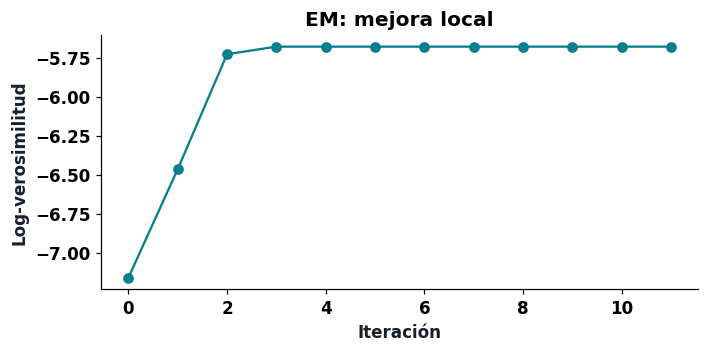

In [3]:
from scipy.special import logsumexp
from scipy.stats import norm
x = np.array([-2., -1., 1., 2.])
weights, means, variances = np.array([.5,.5]), np.array([-1.,1.]), np.ones(2)
history = []
first_step = None
for iteration in range(12):
    log_joint = np.log(weights)[None,:] + norm.logpdf(x[:,None], means, np.sqrt(variances))
    history.append(float(logsumexp(log_joint, axis=1).sum()))
    resp = np.exp(log_joint - logsumexp(log_joint, axis=1, keepdims=True))
    nk = resp.sum(axis=0)
    weights = nk / len(x)
    means = (resp * x[:,None]).sum(axis=0) / nk
    variances = (resp * (x[:,None]-means)**2).sum(axis=0) / nk
    if iteration == 0:
        first_step = (resp.copy(), weights.copy(), means.copy(), variances.copy())
assert np.all(np.diff(history) >= -1e-9)
assert np.allclose(resp.sum(axis=1), 1)
print('Primera iteración: responsabilidades, pesos, medias, varianzas')
for value in first_step: print(value)
fig, ax = plt.subplots(figsize=(7,3))
ax.plot(history, 'o-'); ax.set(xlabel='Iteración', ylabel='Log-verosimilitud', title='EM: mejora local')
savefig(fig, '02_em')

## 3. Primero, un experimento controlado
Estas etiquetas sintéticas identifican cómo generamos los puntos; solo sirven para diagnosticar el experimento.
No se trasladan como verdad al caso real. Compare una elipse larga con una partición por centros.

D:\Documentos\Universidad Externado\Pregrado en Ciencia de Datos\Machine Learning 2\.venv-week4\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "D:\Documentos\Universidad Externado\Pregrado en Ciencia de Datos\Machine Learning 2\.venv-week4\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


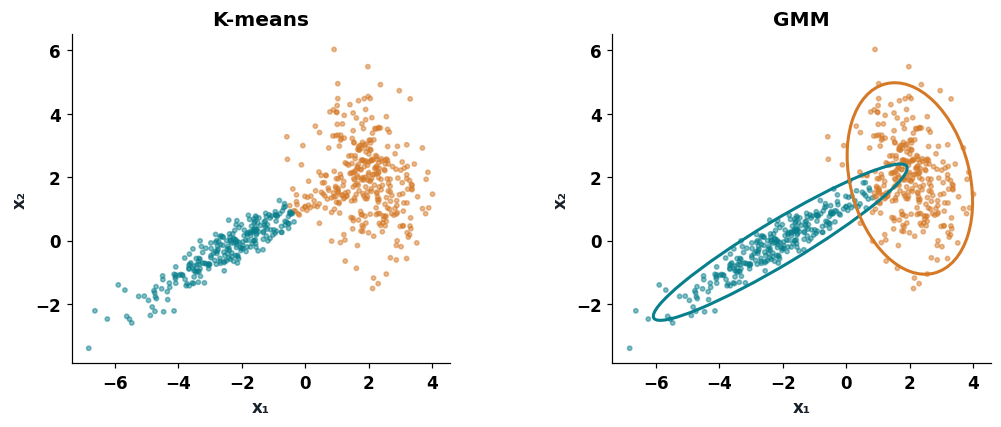

In [4]:
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
rng = np.random.default_rng(42)
Z = np.vstack([rng.multivariate_normal([-2,0], [[3,1.8],[1.8,1.2]], 300),
               rng.multivariate_normal([2,2], [[.8,-.4],[-.4,1.5]], 300)])
gm = GaussianMixture(2, n_init=5, random_state=42).fit(Z)
km = KMeans(2, n_init=10, random_state=42).fit(Z)
fig, axes = plt.subplots(1,2,figsize=(10,4))
for ax, labels, title in zip(axes, [km.labels_,gm.predict(Z)], ['K-means','GMM']):
    ax.scatter(*Z.T, c=np.asarray(COLORS)[labels], s=8, alpha=.5)
    ax.set(title=title, xlabel='x₁', ylabel='x₂', aspect='equal')
ellipses(axes[1],gm)
fig.tight_layout(); savefig(fig, '03_geometria')

## 4. Elegir complejidad sin abrir test
$$\mathrm{BIC}=-2\ell(\widehat\theta)+p\log n,\qquad \mathrm{AIC}=-2\ell(\widehat\theta)+2p.$$
Para covarianza completa, $p=(K-1)+Kd+Kd(d+1)/2$; para diagonal, $p=(K-1)+2Kd$.
Compare BIC únicamente sobre las mismas observaciones y representación. Elegir el menor BIC del conjunto
de candidatos no demuestra un número verdadero de barrios. El ajuste real usa regularización de covarianza.

,k,covariance,bic,aic,converged,iterations,seconds
7,8,full,45282.125171,44967.247978,True,32,0.639734
6,7,full,45358.466757,45083.786652,True,49,0.753069
15,8,diag,46485.980724,46224.699649,True,25,0.322468
5,6,full,46676.172282,46441.689266,True,22,0.457819
4,5,full,46754.025226,46559.739298,True,35,0.564281
14,7,diag,46784.812151,46557.028650,True,22,0.259862
3,4,full,47682.066133,47527.977294,True,10,0.203099
2,3,full,47824.285869,47710.394119,True,15,0.227376
13,6,diag,47908.747799,47714.461871,True,12,0.146584
12,5,diag,47918.294361,47757.506007,True,13,0.138826


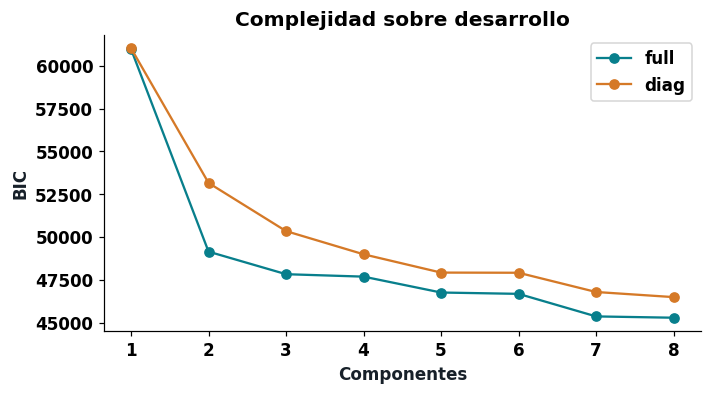

In [5]:
models, rows = {}, []
for covariance in ['full','diag']:
    for k in range(1,9):
        start = time.perf_counter()
        model = GaussianMixture(k, covariance_type=covariance, n_init=5,
                                max_iter=400, reg_covar=1e-5, random_state=42).fit(X)
        rows.append(dict(k=k, covariance=covariance, bic=model.bic(X), aic=model.aic(X),
                         converged=bool(model.converged_), iterations=model.n_iter_,
                         seconds=time.perf_counter()-start))
        models[(k,covariance)] = model
results = pd.DataFrame(rows)
display(results.sort_values('bic'))
valid = results[results.converged]
assert len(valid), 'Ningún candidato convergió; revisar configuración antes de evaluar.'
winner = valid.sort_values('bic').iloc[0]
best = models[(int(winner.k),winner.covariance)]
save_table(results,'gmm_seleccion')
fig, ax = plt.subplots(figsize=(7,3.5))
for covariance in ['full','diag']:
    part = results[results.covariance==covariance]
    ax.plot(part.k,part.bic,'o-',label=covariance)
ax.set(xlabel='Componentes', ylabel='BIC', title='Complejidad sobre desarrollo'); ax.legend()
savefig(fig,'04_bic')

### Para resolver

Si el mínimo ocurre en K=8, ¿qué puede concluir? ¿Se justifica anunciar ocho zonas verdaderas?

**Mi respuesta y evidencia:**

_Escriba aquí su razonamiento; incluya unidades y una limitación._

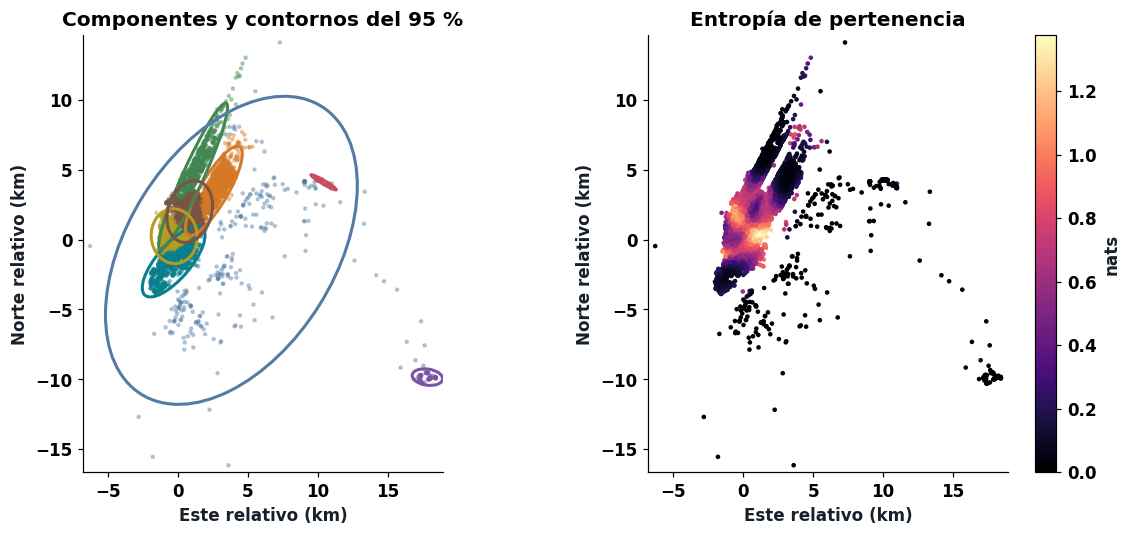

Punto lejano: mayor responsabilidad 1.0
Punto lejano: log-densidad -585.5365994835097


In [6]:
responsibilities = best.predict_proba(X)
entropy = -(responsibilities*np.log(np.maximum(responsibilities,1e-300))).sum(axis=1)
assert np.allclose(responsibilities.sum(axis=1),1)
assert np.isclose(best.weights_.sum(),1)
fig, axes = plt.subplots(1,2,figsize=(11,5))
axes[0].scatter(*X.T,c=np.asarray(COLORS)[best.predict(X)],s=4,alpha=.35)
ellipses(axes[0],best)
points = axes[1].scatter(*X.T,c=entropy,cmap='magma',s=4)
for ax,title in zip(axes,['Componentes y contornos del 95 %','Entropía de pertenencia']):
    spatial_axes(ax,X,title)
fig.colorbar(points,ax=axes[1],label='nats'); fig.tight_layout()
savefig(fig,'05_gmm_espacial')
far = np.array([[X[:,0].max()+100, X[:,1].max()+100]])
print('Punto lejano: mayor responsabilidad',best.predict_proba(far).max())
print('Punto lejano: log-densidad',best.score_samples(far)[0])

## 5. Congelar, después evaluar
La celda siguiente se ejecuta al final. El test mide transferencia temporal a los meses reservados;
no es una estimación universal de la movilidad futura. No se vuelve a seleccionar usando su resultado.

In [7]:
frozen = dict(k=int(winner.k), covariance=str(winner.covariance), seed=42)
test = load_data('test')
Xt = test[['x_km','y_km']].to_numpy()
test['log_density'] = best.score_samples(Xt)
monthly = test.groupby(test.pickup_datetime.dt.month).log_density.agg(['mean','std','count']).reset_index()
display(monthly)
save_table(monthly,'gmm_test_temporal')
print('Configuración congelada:',frozen)
print('Promedio temporal:',test.log_density.mean())

,pickup_datetime,mean,std,count
0,10,-3.697354,1.222333,2615
1,11,-3.733753,1.262606,2358
2,12,-3.743670,1.274392,2338


Configuración congelada: {'k': 8, 'covariance': 'full', 'seed': 42}
Promedio temporal: -3.723905395151227


### Para resolver

Ticket: 1) ¿Qué optimiza EM? 2) ¿Qué significa una responsabilidad de 0.55? 3) ¿Qué no demuestra el BIC?

**Mi respuesta y evidencia:**

_Escriba aquí su razonamiento; incluya unidades y una limitación._

## Fuentes y reproducción
- Microcurrículo y guía docente ML2, sesiones 19–24; adaptación del cuaderno histórico del profesor.
- [GMM](https://scikit-learn.org/stable/modules/mixture.html), [KDE](https://scikit-learn.org/stable/modules/density.html), [clustering](https://scikit-learn.org/stable/modules/clustering.html).
- Dataset suministrado por el docente; ver `datasets/semana-08/README.md` y `manifest.json`.
- Dependencias fijadas en `requirements-week8.txt`. Inicie el kernel en una carpeta del paquete.